In [ ]:
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime

In [ ]:
accounts = pd.read_csv("accounts_clean.csv")
subscriptions = pd.read_csv("subscriptions_clean.csv")
feature_usage = pd.read_csv("feature_usage_clean.csv")
support_ticket_cleaned = pd.read_csv("support_ticket_clean.csv")
churn_events = pd.read_csv("churn_events_clean.csv")

In [ ]:
datasets = {
    "Accounts": accounts,
    "Subscriptions": subscriptions,
    "Feature Usage": feature_usage,
    "Support Tickets": support_ticket_cleaned,
    "Churn Events": churn_events
}
for name, df in datasets.items():
  print(f"{name}: {df.shape}")

Accounts: (500, 13)
Subscriptions: (5000, 16)
Feature Usage: (25000, 9)
Support Tickets: (2000, 10)
Churn Events: (600, 9)


In [ ]:
customer_360 = accounts.merge(subscriptions, on="account_id", how="left")
customer_360.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,mrr_amount,arr_amount,is_trial_y,upgrade_flag,downgrade_flag,churn_flag_y,billing_frequency,auto_renew_flag,subscription_days,revenue_band
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,209,2508,False,False,False,False,monthly,True,NaN,Medium
1,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,980,11760,False,False,False,False,monthly,True,NaN,High
2,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,441,5292,False,False,False,False,monthly,True,NaN,Medium
3,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,1791,21492,False,False,False,False,annual,False,NaN,Enterprise
4,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,1938,23256,False,False,False,False,monthly,True,NaN,Enterprise


In [ ]:
customer_360 = customer_360.merge(feature_usage, on="subscription_id", how="left")
customer_360.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,subscription_days,revenue_band,usage_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,heavy_user
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,NaN,Medium,U-ded235,2024-10-29,feature_11,5.0,480.0,0.0,False,False
1,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,NaN,Medium,U-7d597c,2023-08-01,feature_6,9.0,4599.0,0.0,False,False
2,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,NaN,Medium,U-3edc43,2024-03-05,feature_7,9.0,3564.0,0.0,False,False
3,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,NaN,Medium,U-e073b8,2024-09-01,feature_20,9.0,2700.0,0.0,False,False
4,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,NaN,Medium,U-1b1952,2023-10-07,feature_32,10.0,970.0,0.0,False,True


In [ ]:
customer_360 = customer_360.merge(support_ticket_cleaned, on="account_id", how="left")
customer_360.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,heavy_user,ticket_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag,high_priority
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,T-30b537,2023-09-09,2023-09-10 03:00:00,27.0,urgent,64.0,3.0,False,False
1,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,T-53a3f9,2024-12-10,2024-12-10 19:00:00,19.0,high,118.0,NaN,False,False
2,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,T-30b537,2023-09-09,2023-09-10 03:00:00,27.0,urgent,64.0,3.0,False,False
3,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,T-53a3f9,2024-12-10,2024-12-10 19:00:00,19.0,high,118.0,NaN,False,False
4,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,T-30b537,2023-09-09,2023-09-10 03:00:00,27.0,urgent,64.0,3.0,False,False


In [ ]:
customer_360 = customer_360.merge(churn_events, on="account_id", how="left")
customer_360.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,escalation_flag,high_priority,churn_event_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor
1,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-cea92d,2024-12-05,competitor,0.0,True,False,False,NaN
2,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor
3,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-cea92d,2024-12-05,competitor,0.0,True,False,False,NaN
4,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor


In [ ]:
customer_360.shape

(147896, 53)

In [ ]:
customer_360.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,escalation_flag,high_priority,churn_event_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor
1,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-cea92d,2024-12-05,competitor,0.0,True,False,False,NaN
2,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor
3,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-cea92d,2024-12-05,competitor,0.0,True,False,False,NaN
4,A-2e4581,Company_0,Edtech,Us,2024-10-16,Partner,Basic,9,False,False,...,False,False,C-695fcd,2024-11-23,budget,0.0,False,False,False,switched to competitor


In [ ]:
customer_360.to_csv("customer_360.csv", index=False)

In [ ]:
total_customer = accounts["account_id"].nunique()
print("Total Customers:", total_customer)

Total Customers: 500


In [ ]:
total_subscriptions = subscriptions["subscription_id"].nunique()
print("Total Subscriptions:", total_subscriptions)

Total Subscriptions: 5000


In [ ]:
total_mrr = subscriptions["mrr_amount"].sum()
print(f"Total MRR: ${total_mrr:,.2f}")

Total MRR: $11,338,747.00


In [ ]:
total_arr = subscriptions["arr_amount"].sum()
print(f"Total ARR: ${total_arr:,.2f}")

Total ARR: $136,064,964.00


In [ ]:
average_mrr = subscriptions["mrr_amount"].mean()
print(f"Average MRR: ${average_mrr:,.2f}")


Average MRR: $2,267.75


In [ ]:
churn_rate = (
    accounts["churn_flag"].sum()
    /len(accounts)
) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 22.00%


In [ ]:
avg_satisfaction = support_ticket_cleaned["resolution_time_hours"].mean()
print(f"Average Resolution Time:{avg_satisfaction:.2f} hours")

Average Resolution Time:35.86 hours


In [ ]:
total_refund = churn_events["refund_amount_usd"].sum()
print(f"Total Refund: ${total_refund:,.2f}")

Total Refund: $8,652.25


In [ ]:
churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [ ]:
feature_usage["feature_name"].value_counts().head(10)

,count
feature_name,
feature_12,659
feature_32,659
feature_6,655
feature_17,651
feature_34,650
feature_26,649
feature_36,648
feature_31,644
feature_11,643


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Subscriptions",
        "Total MRR",
        "Total ARR",
        "Average MRR",
        "Churn Rate",
        "Average Resolution Time",
        "Total Refund"
    ],
    "Value": [
        total_customer,
        total_subscriptions,
        total_mrr,
        total_arr,
        average_mrr,
        churn_rate,
        avg_satisfaction,
        total_refund
    ]

})

In [ ]:
kpi_summary.to_csv("kpi_summary.csv", index = False)

In [ ]:
industry_summary = (
    accounts.groupby("industry").agg(
        Total_Customers = ("account_id", "count")
    )
    .sort_values("Total_Customers", ascending=False)

)
industry_summary

,Total_Customers
industry,
Devtools,113
Fintech,112
Cybersecurity,100
Healthtech,96
Edtech,79


In [ ]:
industry_summary.to_csv("industry_summary.csv")

In [ ]:
billing_summary = (
    subscriptions.groupby("billing_frequency").agg(
        Total_Subscriptions = ("subscription_id", "count"),
        Total_MRR = ("mrr_amount", "sum"),
        Average_MRR = ("arr_amount", "mean")
    )
)
billing_summary

,Total_Subscriptions,Total_MRR,Average_MRR
billing_frequency,,,
annual,2461,5597398,27293.285656
monthly,2539,5741349,27135.166601


In [ ]:
feature_summary = (
    feature_usage.groupby("feature_name").agg(
        Total_Usage = ("usage_count", "sum")
    )
    .sort_values("Total_Usage", ascending=False)

)
feature_summary.head(10)

,Total_Usage
feature_name,
feature_32,6686
feature_15,6621
feature_6,6546
feature_20,6541
feature_34,6536
feature_12,6534
feature_11,6533
feature_2,6525
feature_38,6478


In [ ]:
priority_summary = (
    support_ticket_cleaned.groupby("priority").size()
        .reset_index(name="Total_Tickets")

    )

priority_summary


,priority,Total_Tickets
0,high,510
1,low,485
2,medium,491
3,urgent,514


In [ ]:
churn_reason_summary = (
    churn_events.groupby("reason_code").size()
        .reset_index(name="Customers")
        .sort_values("Customers", ascending=False)
)
churn_reason_summary

,reason_code,Customers
2,features,114
0,budget,104
4,support,104
5,unknown,95
1,competitor,92
3,pricing,91


In [ ]:
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])

monthly_revenue = (
    subscriptions.groupby(
        subscriptions["start_date"].dt.to_period("M")
    ).agg(
        Total_Revenue = ("mrr_amount", "sum")
    )
  )
monthly_revenue

,Total_Revenue
start_date,
2023-01,4684
2023-02,11079
2023-03,25885
2023-04,41788
2023-05,85919
2023-06,74987
2023-07,120422
2023-08,165621
2023-09,116222


In [ ]:
billing_summary.to_csv("billing_summary.csv")
feature_summary.to_csv("feature_summary.csv")
priority_summary.to_csv("priority_summary.csv")
churn_reason_summary.to_csv("churn_reason_summary.csv")
monthly_revenue.to_csv("monthly_revenue.csv")

In [ ]:
monthly_revenue.to_csv("monthly_revenue.csv")

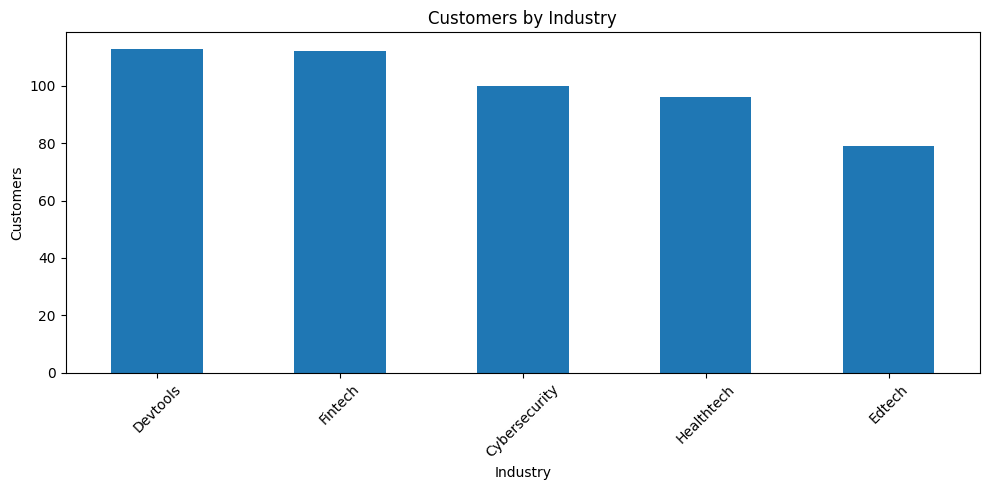

In [58]:
import matplotlib.pyplot as plt

industry_summary.reset_index().sort_values("Total_Customers", ascending=False).plot(
    kind="bar",
    x="industry",
    y="Total_Customers",
    figsize=(10,5),
    legend=False
)

plt.title("Customers by Industry")
plt.xlabel("Industry")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

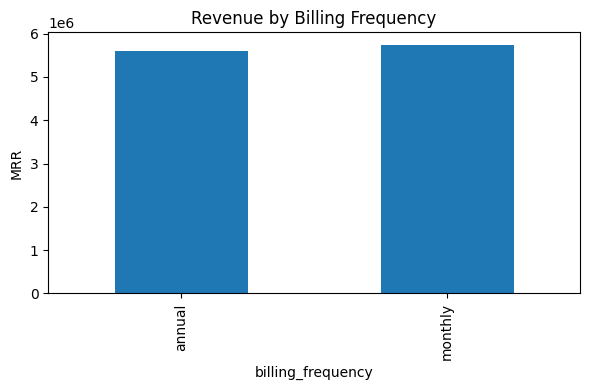

In [59]:
billing_summary.plot(
    kind="bar",
    y="Total_MRR",
    figsize=(6,4),
    legend=False
)

plt.title("Revenue by Billing Frequency")
plt.ylabel("MRR")
plt.tight_layout()
plt.show()

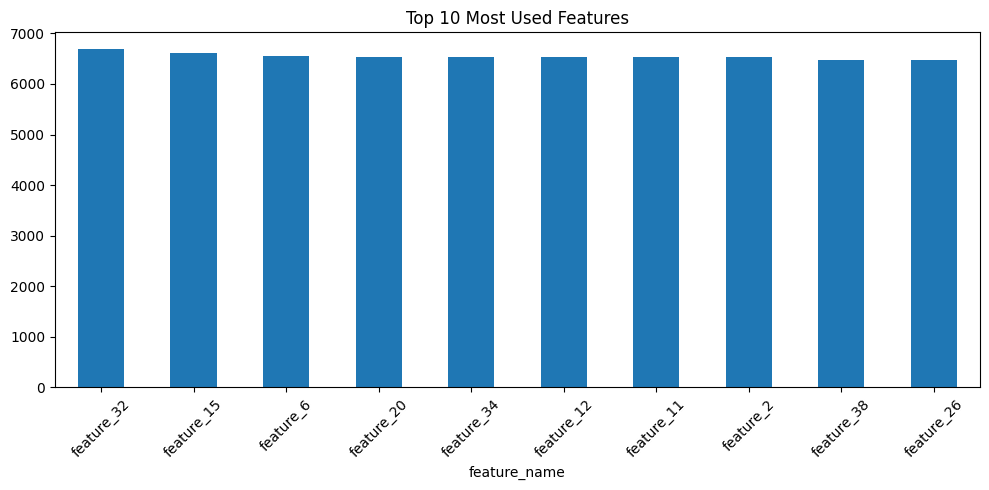

In [61]:
feature_summary.head(10).reset_index().plot(
    kind="bar",
    x="feature_name",
    y="Total_Usage",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Most Used Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

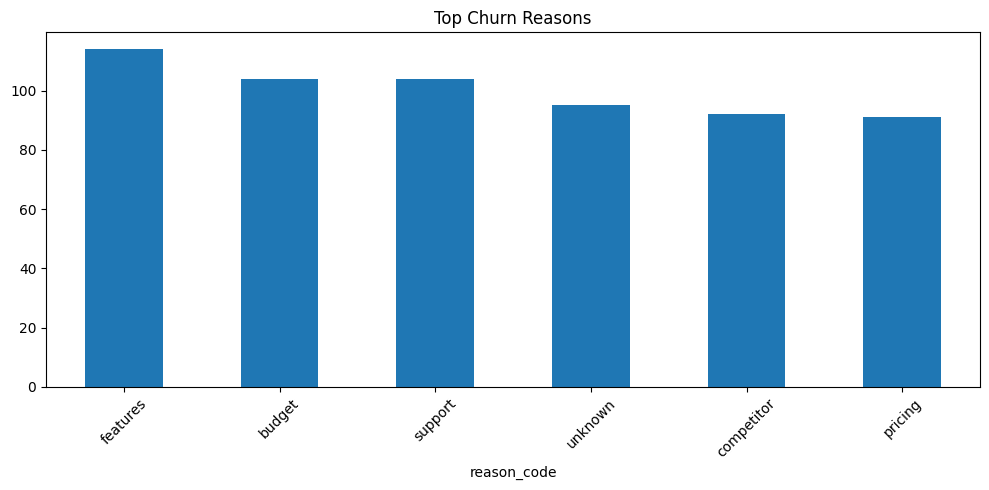

In [63]:
churn_reason_summary.plot(
    kind="bar",
    x="reason_code",
    y="Customers",
    figsize=(10,5),
    legend=False
)

plt.title("Top Churn Reasons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
plt.savefig("industry_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [65]:
plt.savefig("billing_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [66]:
plt.savefig("feature_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [67]:
plt.savefig("churn_reason_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>